In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

In [2]:
now = datetime.now()

start=datetime(now.year-10,now.month,now.day)
end=now
data="TSLA"
df=yf.download(data,start,end)
df

/tmp/ipykernel_33331/3719004746.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(data,start,end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2016-04-29,16.050667,16.562000,15.854000,16.542667,81207000
2016-05-02,16.120001,16.212667,15.654667,16.100000,57658500
2016-05-03,15.488000,15.927333,15.441333,15.824000,64533000
2016-05-04,14.837333,15.630667,14.693333,15.352667,130507500
2016-05-05,14.102000,15.242667,13.986000,15.230667,168822000
...,...,...,...,...,...
2026-04-23,373.720001,386.000000,368.390015,375.279999,93969500
2026-04-24,376.299988,382.760010,370.730011,373.500000,62893300


In [3]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2026-04-23,373.720001,386.000000,368.390015,375.279999,93969500
2026-04-24,376.299988,382.760010,370.730011,373.500000,62893300
2026-04-27,378.670013,380.779999,364.019989,372.089996,66735800
2026-04-28,376.019989,382.290009,372.540009,374.679993,50698300
2026-04-29,371.130005,376.399994,370.040009,375.390015,25257377


In [4]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [5]:
df.shape

(2514, 5)

In [6]:
df.isnull().sum()

,,0
Price,Ticker,
Close,TSLA,0
High,TSLA,0
Low,TSLA,0
Open,TSLA,0
Volume,TSLA,0


In [7]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,2514.000000,2514.000000,2514.000000,2514.000000,2.514000e+03
mean,162.226898,165.771173,158.552763,162.278129,1.149949e+08
std,135.976365,138.899893,133.031778,136.108974,7.271200e+07
min,11.931333,12.315333,11.799333,12.073333,2.489250e+07
25%,21.301166,21.622500,20.881667,21.225832,7.044090e+07
50%,176.644997,179.680000,173.135002,175.955002,9.581350e+07
75%,259.087502,263.885010,252.777504,258.069992,1.317086e+08
max,489.880005,498.829987,485.329987,489.880005,9.140820e+08


In [8]:
df.dtypes

,,0
Price,Ticker,
Close,TSLA,float64
High,TSLA,float64
Low,TSLA,float64
Open,TSLA,float64
Volume,TSLA,int64


In [9]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2016-04-29,16.050667,16.562000,15.854000,16.542667,81207000
2016-05-02,16.120001,16.212667,15.654667,16.100000,57658500
2016-05-03,15.488000,15.927333,15.441333,15.824000,64533000
2016-05-04,14.837333,15.630667,14.693333,15.352667,130507500
2016-05-05,14.102000,15.242667,13.986000,15.230667,168822000


In [10]:
df.reset_index()
df.head()


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2016-04-29,16.050667,16.562000,15.854000,16.542667,81207000
2016-05-02,16.120001,16.212667,15.654667,16.100000,57658500
2016-05-03,15.488000,15.927333,15.441333,15.824000,64533000
2016-05-04,14.837333,15.630667,14.693333,15.352667,130507500
2016-05-05,14.102000,15.242667,13.986000,15.230667,168822000


Text(0.5, 1.0, 'TSLA')

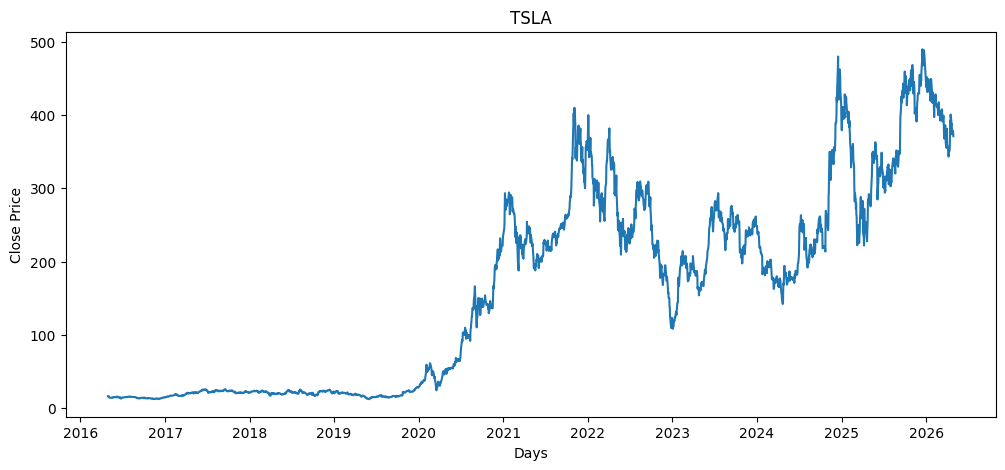

In [11]:
plt.figure(figsize = (12,5))
plt.plot(df.Close)
plt.xlabel('Days')
plt.ylabel('Close Price')
plt.title(data)

In [12]:
temp_data = [10, 15, 20, 18, 30, 22, 25, 32, 35, 38]
print(sum(temp_data[1:6])/5)

21.0


In [13]:
df1 = pd.DataFrame([10,15,20,18,30,22,25,32,35,38])
df1

,0
0,10
1,15
2,20
3,18
4,30
5,22
6,25
7,32
8,35
9,38


In [14]:
df1['MA_1']=df1.rolling(5).mean()
df1

,0,MA_1
0,10,NaN
1,15,NaN
2,20,NaN
3,18,NaN
4,30,18.6
5,22,21.0
6,25,23.0
7,32,25.4
8,35,28.8
9,38,30.4


**100 Days of Moving Average**



In [15]:
df['MA_100']=df.Close.rolling(100).mean()

In [16]:
df['MA_100'].head(102)

,MA_100
Date,
2016-04-29,NaN
2016-05-02,NaN
2016-05-03,NaN
2016-05-04,NaN
2016-05-05,NaN
...,...
2016-09-16,NaN
2016-09-19,NaN
2016-09-20,14.488320


Text(0.5, 1.0, '100 Days Moving Average')

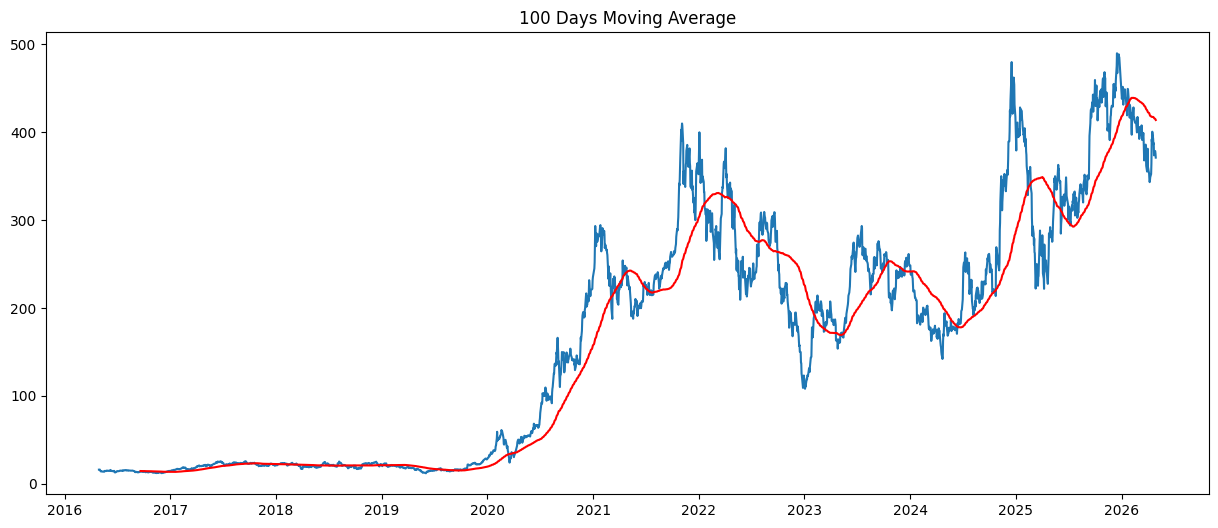

In [17]:
plt.figure(figsize=(15,6))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.title('100 Days Moving Average')

**200 Days of Moving Average**

In [18]:
df['MA_200']=df.Close.rolling(200).mean()

In [19]:
df['MA_200'].head(203)

,MA_200
Date,
2016-04-29,NaN
2016-05-02,NaN
2016-05-03,NaN
2016-05-04,NaN
2016-05-05,NaN
...,...
2017-02-10,NaN
2017-02-13,14.310513
2017-02-14,14.323920


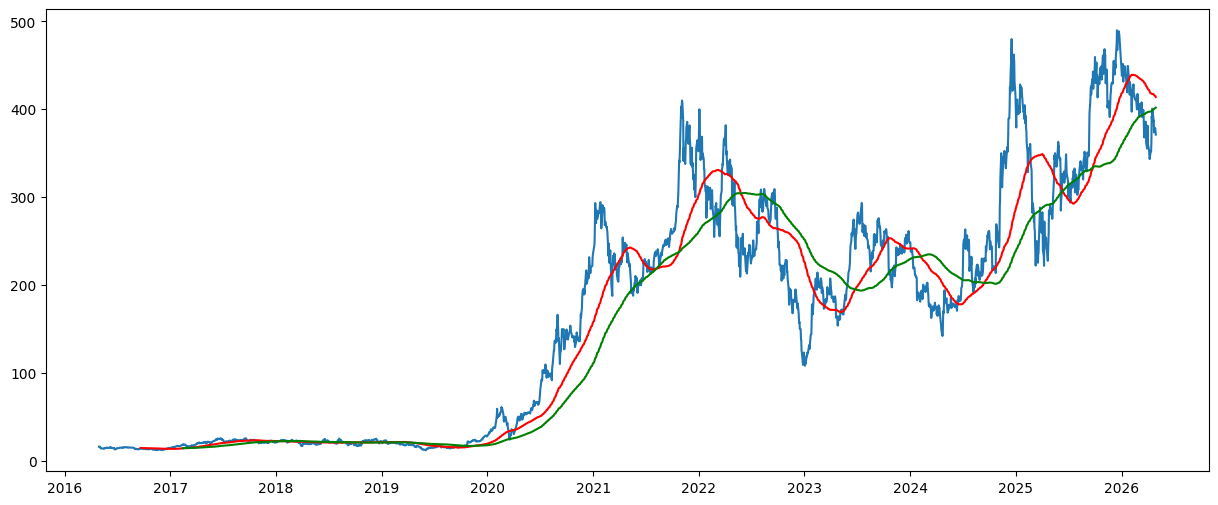

In [20]:
plt.figure(figsize=(15,6))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')

In [21]:
df['Percentage Changed']=df.Close.pct_change()
df[['Close', 'Percentage Changed']]

Price,Close,Percentage Changed
Ticker,TSLA,
Date,,
2016-04-29,16.050667,NaN
2016-05-02,16.120001,0.004320
2016-05-03,15.488000,-0.039206
2016-05-04,14.837333,-0.042011
2016-05-05,14.102000,-0.049560
...,...,...
2026-04-23,373.720001,-0.035586
2026-04-24,376.299988,0.006904


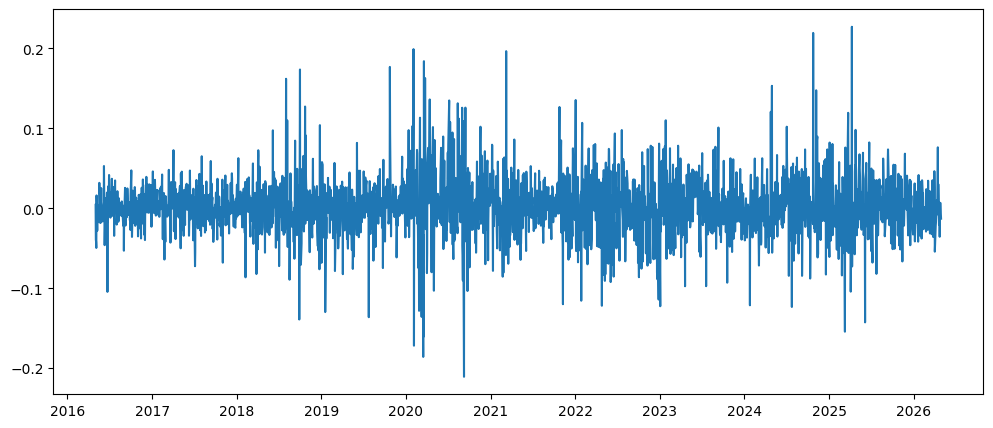

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage Changed'])

In [23]:
from sklearn.model_selection import train_test_split
data1 = df[['Close']]

data_training, data_testing = train_test_split(
    data1,
    test_size=0.30,
    shuffle=False  # IMPORTANT for time series
)

In [24]:
print(data_training.shape)

(1759, 1)


In [25]:
print(data_testing.shape)

(755, 1)


In [26]:
# Normalizing data to 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [27]:
data_training_array=scaler.fit_transform(data_training)
data_training_array

array([[0.01034908],
       [0.01052327],
       [0.00893548],
       ...,
       [0.38475827],
       [0.37840211],
       [0.37367893]])

In [28]:
x_train=[]
y_train=[]

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train,y_train=np.array(x_train),np.array(y_train)

In [29]:
x_train.shape

(1659, 100, 1)

In [30]:
y_train.shape

(1659,)

In [31]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [32]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [33]:
model = Sequential()

model.add(Input(shape=(100,1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

In [34]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 186ms/step - loss: 0.0084
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step - loss: 0.0012
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - loss: 0.0011
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - loss: 9.7045e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - loss: 8.5560e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - loss: 8.3029e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - loss: 9.4323e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - loss: 8.2639e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - loss: 6.6431e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - loss: 6.2629e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - loss: 6.2857e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - loss: 6.8010e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - loss: 6.5218e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - loss: 5.4539e-04
Epoc

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [36]:
model.save('stock_prediction_model.keras')

In [37]:
past_100_days=data_training.tail(100)

In [38]:
past_100_days

Price,Close
Ticker,TSLA
Date,
2022-11-30,194.699997
2022-12-01,194.699997
2022-12-02,194.860001
2022-12-05,182.449997
2022-12-06,179.820007
...,...
2023-04-19,180.589996
2023-04-20,162.990005


In [39]:
final_df = pd.concat([past_100_days,data_testing],ignore_index=True)
final_df

Price,Close
Ticker,TSLA
0,194.699997
1,194.699997
2,194.860001
3,182.449997
4,179.820007
...,...
850,373.720001
851,376.299988
852,378.670013


In [40]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.2268322 ],
       [0.2268322 ],
       [0.2272513 ],
       [0.19474566],
       [0.1878569 ],
       [0.17271726],
       [0.17114569],
       [0.18584002],
       [0.15642519],
       [0.1384305 ],
       [0.12756038],
       [0.12983917],
       [0.1103515 ],
       [0.10940855],
       [0.0777935 ],
       [0.07719107],
       [0.04518309],
       [0.03942062],
       [0.00261931],
       [0.01207502],
       [0.03593693],
       [0.03949919],
       [0.        ],
       [0.01451098],
       [0.00586725],
       [0.01299177],
       [0.03056734],
       [0.02815758],
       [0.03960397],
       [0.04049452],
       [0.03745613],
       [0.06126567],
       [0.05416732],
       [0.04995023],
       [0.06632092],
       [0.09337839],
       [0.09374509],
       [0.0951595 ],
       [0.13664939],
       [0.18282779],
       [0.15338678],
       [0.17056944],
       [0.19202159],
       [0.20999006],
       [0.21446906],
       [0.22698935],
       [0.23235894],
       [0.244

In [41]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])


x_test, y_test = np.array(x_test), np.array(y_test)

**Making Predictions**

In [42]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step


In [43]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

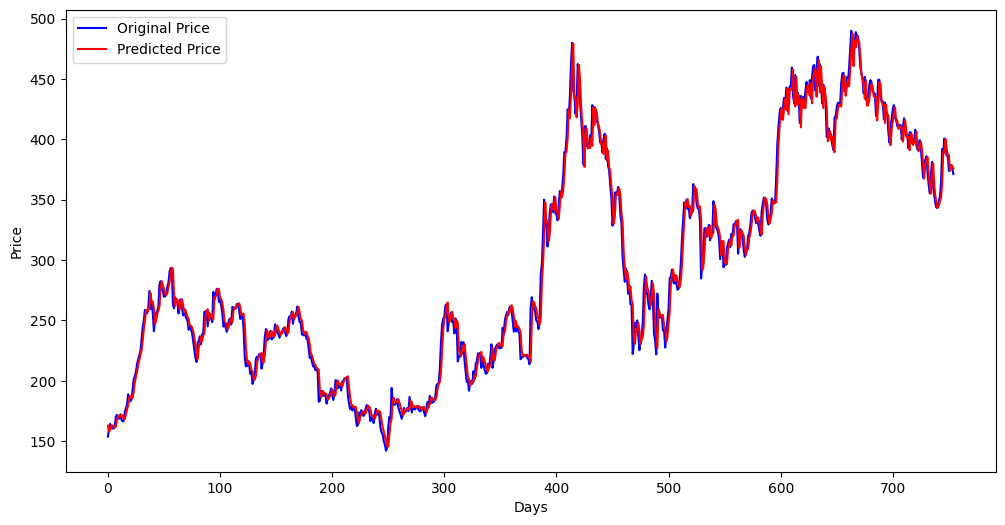

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

In [45]:
from sklearn.metrics import mean_squared_error, r2_score

In [46]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 115.93167771867645


In [47]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 10.767157364814375


In [48]:
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.9859667442084795
